# 베티아잉글리시 앱 리뷰 분석

## 패키지 import

In [62]:
# import os
# import random #데이터 샘플링
# from collections import Counter # count 용도

import numpy as np
import pandas as pd

# from geopy import distance # 거리 계산
# import geopy.distance
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('fivethirtyeight')

# 한글, 마이너스 깨짐 방지
from matplotlib import rc, font_manager, rcParams
font=font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family = font)
rcParams['axes.unicode_minus'] = False

## 데이터 불러오기

In [63]:
df = pd.read_csv('./dataset/review_dataset.csv')
df = df.drop(['Unnamed: 0'], axis = 1) # 불필요한 칼럼 삭제
df.head()

,id,date,dateYear,dateMonth,dateDay,rating,userName,content
0,1,20220210,2022,2,10,4,반혜영,업데이트 하라고 해서 했는데 자꾸 업데이트 하라고 나오고 앱스토어에는 이미 되어있다...
1,2,20220125,2022,1,25,5,Jessica Cha,영어공부에 대한 진입장벽이 거의 없고 게임인듯 게임아닌 영어공부를 할 수 있어서 좋...
2,3,20211223,2021,12,23,5,Hil Sa,할 게임 없나 찾아보다 발견해서 20분 정도 해본 거 같아요. 게임은 요즘 게임들처...
3,4,20211231,2021,12,31,5,나영,영어게임 중 가장 좋은 거 같아요! 근데 그 스토리 빼고 다 유료인가요..? 한 번...
4,5,20211217,2021,12,17,5,박범진,그냥 게임인줄 알고 베티아 잉글리시를 해보니 1. 아이들 뿐 아니라 남녀노소 영어 ...


In [64]:
df.tail()

,id,date,dateYear,dateMonth,dateDay,rating,userName,content
287,288,20211211,2021,12,11,5,이현주,굿
288,289,20211208,2021,12,8,5,JOY HONG,영어재밌당
289,290,20211220,2021,12,20,1,신용준,이거애들이 영어못하는데왜 다른부모님이이거만들앤들이다영어못해그만그만들어엥
290,291,20211224,2021,12,24,3,마니,I think this is for preschool. It might be bet...
291,292,20220121,2022,1,21,5,김김선혜,👍 최고


In [65]:
for col in df.columns:
    print(f"column : {col}")
    print(f"The number of unique : {df[col].nunique()}")
    print()

column : id
The number of unique : 292

column : date
The number of unique : 67

column : dateYear
The number of unique : 2

column : dateMonth
The number of unique : 3

column : dateDay
The number of unique : 30

column : rating
The number of unique : 5

column : userName
The number of unique : 291

column : content
The number of unique : 292



In [66]:
df.shape

(292, 8)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         292 non-null    int64 
 1   date       292 non-null    int64 
 2   dateYear   292 non-null    int64 
 3   dateMonth  292 non-null    int64 
 4   dateDay    292 non-null    int64 
 5   rating     292 non-null    int64 
 6   userName   292 non-null    object
 7   content    292 non-null    object
dtypes: int64(6), object(2)
memory usage: 18.4+ KB


In [68]:
# 결측치 확인
df.isnull().sum()

id           0
date         0
dateYear     0
dateMonth    0
dateDay      0
rating       0
userName     0
content      0
dtype: int64

## 데이터 전처리

### 필요없는 컬럼 삭제

In [69]:
drop_col = ['dateYear', 'dateMonth', 'dateDay']
df.drop(drop_col, axis=1, inplace=True)
df

,id,date,rating,userName,content
0,1,20220210,4,반혜영,업데이트 하라고 해서 했는데 자꾸 업데이트 하라고 나오고 앱스토어에는 이미 되어있다...
1,2,20220125,5,Jessica Cha,영어공부에 대한 진입장벽이 거의 없고 게임인듯 게임아닌 영어공부를 할 수 있어서 좋...
2,3,20211223,5,Hil Sa,할 게임 없나 찾아보다 발견해서 20분 정도 해본 거 같아요. 게임은 요즘 게임들처...
3,4,20211231,5,나영,영어게임 중 가장 좋은 거 같아요! 근데 그 스토리 빼고 다 유료인가요..? 한 번...
4,5,20211217,5,박범진,그냥 게임인줄 알고 베티아 잉글리시를 해보니 1. 아이들 뿐 아니라 남녀노소 영어 ...
...,...,...,...,...,...
287,288,20211211,5,이현주,굿
288,289,20211208,5,JOY HONG,영어재밌당
289,290,20211220,1,신용준,이거애들이 영어못하는데왜 다른부모님이이거만들앤들이다영어못해그만그만들어엥
290,291,20211224,3,마니,I think this is for preschool. It might be bet...


### 날짜 타입 변경

In [70]:
df['date'] = pd.to_datetime(df['date'].astype('str'))
df.head()

,id,date,rating,userName,content
0,1,2022-02-10,4,반혜영,업데이트 하라고 해서 했는데 자꾸 업데이트 하라고 나오고 앱스토어에는 이미 되어있다...
1,2,2022-01-25,5,Jessica Cha,영어공부에 대한 진입장벽이 거의 없고 게임인듯 게임아닌 영어공부를 할 수 있어서 좋...
2,3,2021-12-23,5,Hil Sa,할 게임 없나 찾아보다 발견해서 20분 정도 해본 거 같아요. 게임은 요즘 게임들처...
3,4,2021-12-31,5,나영,영어게임 중 가장 좋은 거 같아요! 근데 그 스토리 빼고 다 유료인가요..? 한 번...
4,5,2021-12-17,5,박범진,그냥 게임인줄 알고 베티아 잉글리시를 해보니 1. 아이들 뿐 아니라 남녀노소 영어 ...


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        292 non-null    int64         
 1   date      292 non-null    datetime64[ns]
 2   rating    292 non-null    int64         
 3   userName  292 non-null    object        
 4   content   292 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ KB


## 데이터 분석

### 연도 및 월별 리뷰 추이

In [72]:
df.groupby(df.date.dt.year).count()

,id,date,rating,userName,content
date,,,,,
2021,111,111,111,111,111
2022,181,181,181,181,181


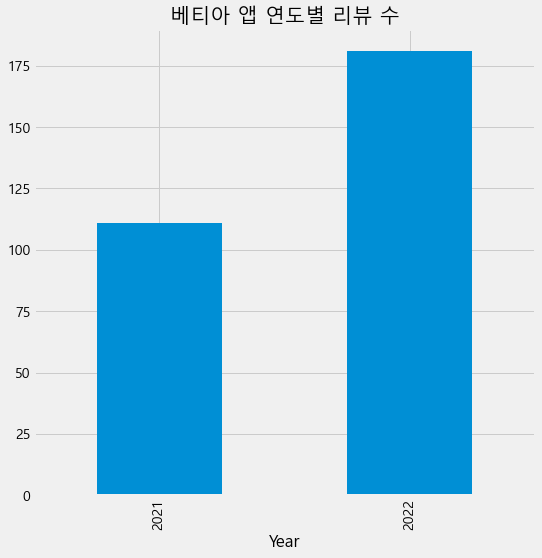

In [73]:
# 년도별 평가수 살펴보기
plt.figure(figsize=(8, 8))
df.groupby(df.date.dt.year).count()['date'].plot(kind='bar')
plt.xlabel('Year')
plt.title('베티아 앱 연도별 리뷰 수')
plt.show()

In [74]:
df.groupby(df.date.dt.month).count()

,id,date,rating,userName,content
date,,,,,
1,141,141,141,141,141
2,40,40,40,40,40
12,111,111,111,111,111


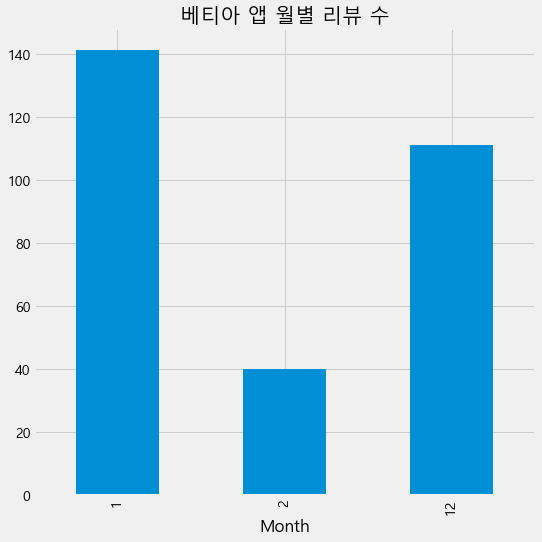

In [75]:
# 월별 평가수 살펴보기
plt.figure(figsize=(8, 8))
df.groupby(df.date.dt.month).count()['date'].plot(kind='bar')
plt.xlabel('Month')
plt.title('베티아 앱 월별 리뷰 수')
plt.show()

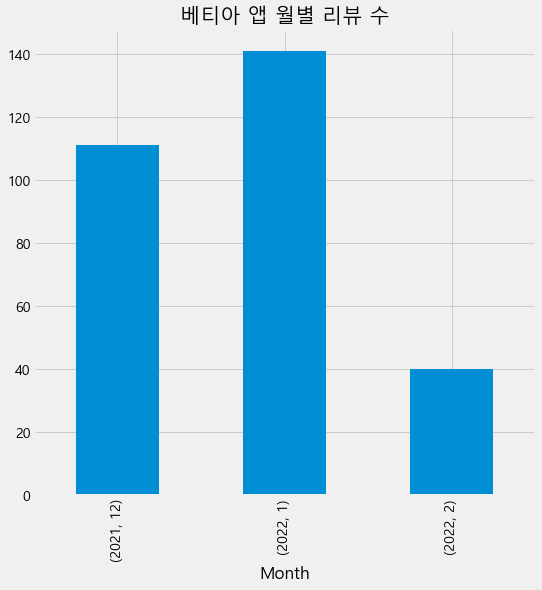

In [76]:
# 월별 평가수 살펴보기
plt.figure(figsize=(8, 8))
df.groupby([df.date.dt.year, df.date.dt.month]).count()['date'].plot(kind='bar')
plt.xlabel('Month')
plt.title('베티아 앱 월별 리뷰 수')
plt.show()

+ 2021년 11월 12일에 출시됨

### 리뷰 형태소 분석

In [1]:
from konlpy.tag import Okt
okt = Okt()

In [41]:
# 형태소 나눠주기
sentences = []
for cp in tqdm(df.content.dropna()):
    sentences.append(okt.pos(cp))

100%|████████████████████████████████████████████████████████████████████████████████| 292/292 [00:06<00:00, 44.95it/s]


In [43]:
sentences[0]

[('업데이트', 'Noun'),
 ('하라', 'Noun'),
 ('고', 'Josa'),
 ('해서', 'Verb'),
 ('했는데', 'Verb'),
 ('자꾸', 'Noun'),
 ('업데이트', 'Noun'),
 ('하라', 'Noun'),
 ('고', 'Josa'),
 ('나오고', 'Verb'),
 ('앱스토어', 'Noun'),
 ('에는', 'Josa'),
 ('이미', 'Adverb'),
 ('되어있다고', 'Verb'),
 ('표시', 'Noun'),
 ('되네요', 'Verb'),
 ('제거', 'Noun'),
 ('하고', 'Josa'),
 ('새로', 'Adjective'),
 ('깔아도', 'Verb'),
 ('계속', 'Noun'),
 ('안되요', 'Adjective')]

In [44]:
# 조사, 구두점 제거
words = []
for sentence in tqdm(sentences):
    for word, tag in sentence:
        if tag not in ['Josa', 'Punctuation']:
            words.append(word)

100%|█████████████████████████████████████████████████████████████████████████████| 292/292 [00:00<00:00, 58571.82it/s]


In [46]:
words

['업데이트',
 '하라',
 '해서',
 '했는데',
 '자꾸',
 '업데이트',
 '하라',
 '나오고',
 '앱스토어',
 '이미',
 '되어있다고',
 '표시',
 '되네요',
 '제거',
 '새로',
 '깔아도',
 '계속',
 '안되요',
 '영어',
 '공부',
 '대한',
 '진입',
 '장벽',
 '거의',
 '없고',
 '게임',
 '듯',
 '게임',
 '아닌',
 '영어',
 '공부',
 '할',
 '수',
 '있어서',
 '좋아요',
 '자기주도',
 '학습',
 '가능해서',
 '아이',
 '스스로',
 '한다는',
 '것',
 '가장',
 '큰',
 '장점',
 '이',
 '영어',
 '말',
 '하기에',
 '대해',
 '흥미',
 '생기',
 '자신감',
 '생겼네요',
 '가끔',
 '오류',
 '나',
 '꾸준히',
 '해결',
 '중',
 '것',
 '같구요',
 '스토리',
 '더',
 '늘어났음',
 '좋겠습니다',
 '할',
 '게임',
 '없나',
 '찾아보다',
 '발견',
 '해서',
 '20분',
 '정도',
 '해본',
 '거',
 '같아요',
 '게임',
 '요즘',
 '게임',
 '들',
 '세련',
 '됐고',
 '게임',
 '성도',
 '나름',
 '있네요',
 '음성인식',
 '잘',
 '되는',
 '편이구요',
 '혹시',
 '처음',
 '캐릭터',
 '소속',
 '학교',
 '고르는',
 '것',
 '따라',
 '학습',
 '수준',
 '바뀌는지',
 '궁금합니다',
 '고등학교',
 '이상',
 '했는데',
 '생각',
 '초',
 '급',
 '요',
 '타겟',
 '층',
 '어린',
 '연령',
 '대',
 '싶습니다',
 '영어',
 '게임',
 '중',
 '가장',
 '좋은',
 '거',
 '같아요',
 '근데',
 '그',
 '스토리',
 '빼고',
 '다',
 '유료',
 '한',
 '번',
 '하고',
 '구매',
 '해야하던데',
 '전',
 '무료',
 '좋은데',
 '게임',
 

In [47]:
from wordcloud import WordCloud
def makeWordcloud(words, cmap='RdBu', title=None):
    wordcloud = WordCloud(font_path='C:/Windows/Fonts/Malgun.ttf', background_color='white',
                          width=1500, colormap=cmap, height=1000).generate_from_frequencies(words)
    plt.figure(figsize=(15, 8))
    plt.title(title)
    plt.imshow(wordcloud)

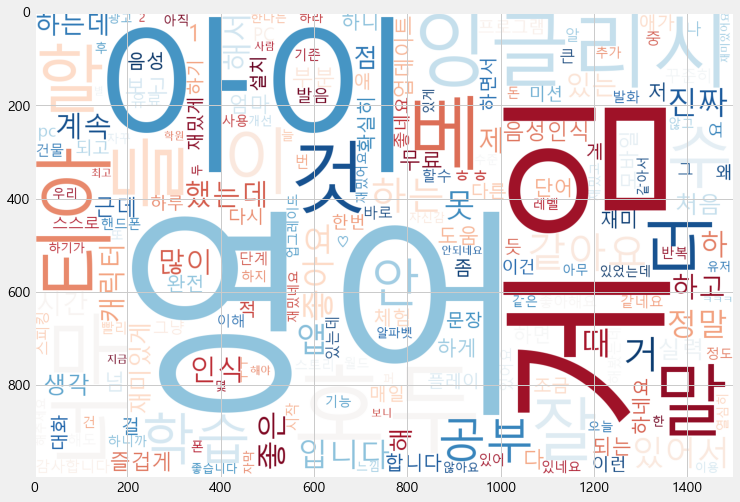

In [48]:
from collections import Counter
countword = Counter(words)
makeWordcloud(countword)

In [17]:
# 3점 리뷰
df[df['rating']==3]

,id,date,rating,userName,content
12,13,2021-12-11,3,김강희,몇 년 전 호두 잉글리시 플레이했던 유저입니다. 그림체 보고 바로 알아봤네요. 당시...
15,16,2021-12-20,3,Merry JJ,말을 하는데 못 알아 듣고요 긴 글씨는 읽을 시간을 줘야하는데 시간도 너무 적은거 ...
49,50,2021-12-17,3,김지혜,로그인했는데 캐릭터 생성부터 막히네요... 호두 피시랑 모바일 둘다하고 있는데 .....
60,61,2021-12-06,3,JungHoon Lee,디노가 I can't hear you! 라면서 더 이상 진행이 안되네요. 마이크 소...
118,119,2022-01-02,3,은멍이의 마인크래프트,음....유료여서 잘 못하겠네요 다 한번하고 유료라니...부모님의 허락이 없으면 잘...
123,124,2021-12-13,3,뽀라,너무 쉬워요.. 완전 초등학교 수준이라 할 맛이 안 나네요 공부도 전혀 안 되는 것...
266,267,2021-12-15,3,J,아니 왜 설치가 안될까요....ㅠㅠ
290,291,2021-12-24,3,마니,I think this is for preschool. It might be bet...


In [62]:
df[df['rating']<4]

,id,date,rating,userName,content
12,13,2021-12-11,3,김강희,몇 년 전 호두 잉글리시 플레이했던 유저입니다. 그림체 보고 바로 알아봤네요. 당시...
15,16,2021-12-20,3,Merry JJ,말을 하는데 못 알아 듣고요 긴 글씨는 읽을 시간을 줘야하는데 시간도 너무 적은거 ...
25,26,2022-02-04,1,한채원,오마이비키 광고 보고 재미있어 보여서 바로 설치했는데 머..영어 퀴즈 몇게하고 나니...
30,31,2021-12-03,1,Jin Yeong Lim,아직 출시된 지 얼마 안되어서 그런건지 모르겠지만 깔고 1분도 되지않고 작성하는 후...
38,39,2021-12-16,1,개콩이,설치 후 들어가니까 자꾸 최신앱을 사용하래요! 업데이트 안 됐다구.. 그래서 삭제하...
49,50,2021-12-17,3,김지혜,로그인했는데 캐릭터 생성부터 막히네요... 호두 피시랑 모바일 둘다하고 있는데 .....
59,60,2022-02-06,1,허성은,진짜 짜증나게 한나 있어요 기억 다시 나게하는 거기에서 한번 따라서 계속해도 안된서...
60,61,2021-12-06,3,JungHoon Lee,디노가 I can't hear you! 라면서 더 이상 진행이 안되네요. 마이크 소...
67,68,2021-12-06,1,최미순,깔고 바로 실행하는데 ㅜㅜ 음성인식이 안되네요. 겨우 하나 넘기고 계속 안되니 애가...
71,72,2022-02-11,1,유복순,저는 이 앱을 플래이 하려고 했는데 최신 기술로 업데이트 하라고해서 업데이트하려는데...


In [132]:
len(df[df['rating']<4])

51

In [63]:
df[df['rating']<4].loc[12, 'content']

'몇 년 전 호두 잉글리시 플레이했던 유저입니다. 그림체 보고 바로 알아봤네요. 당시 스토리 업데이트가 느리고 온갖 오류가 난무해서 이용날짜가 상당히 남아있었음에도 불구하고 플레이를 관뒀던 기억이 있습니다. 많이 개선되었을까요? 그때는 이용권을 구매하고 진행했었는데 이번에는 결제가 필요없는건지 궁금해서 다시 한 번 해봅니다ㅎ'

In [64]:
df[df['rating']>3]

,id,date,rating,userName,content
0,1,2022-02-10,4,반혜영,업데이트 하라고 해서 했는데 자꾸 업데이트 하라고 나오고 앱스토어에는 이미 되어있다...
1,2,2022-01-25,5,Jessica Cha,영어공부에 대한 진입장벽이 거의 없고 게임인듯 게임아닌 영어공부를 할 수 있어서 좋...
2,3,2021-12-23,5,Hil Sa,할 게임 없나 찾아보다 발견해서 20분 정도 해본 거 같아요. 게임은 요즘 게임들처...
3,4,2021-12-31,5,나영,영어게임 중 가장 좋은 거 같아요! 근데 그 스토리 빼고 다 유료인가요..? 한 번...
4,5,2021-12-17,5,박범진,그냥 게임인줄 알고 베티아 잉글리시를 해보니 1. 아이들 뿐 아니라 남녀노소 영어 ...
...,...,...,...,...,...
285,286,2021-12-18,5,황미라,잼
286,287,2021-12-11,5,율이화이팅,최고예요!
287,288,2021-12-11,5,이현주,굿
288,289,2021-12-08,5,JOY HONG,영어재밌당


100%|█████████████████████████████████████████████████████████████████████████████| 241/241 [00:00<00:00, 80717.66it/s]


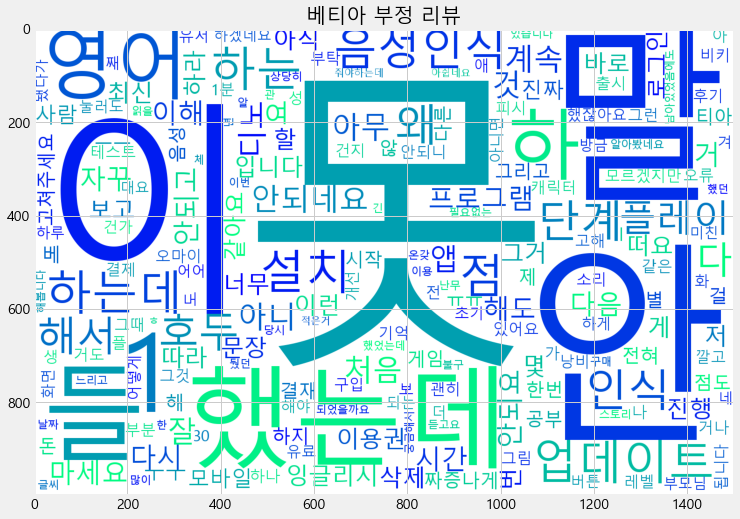

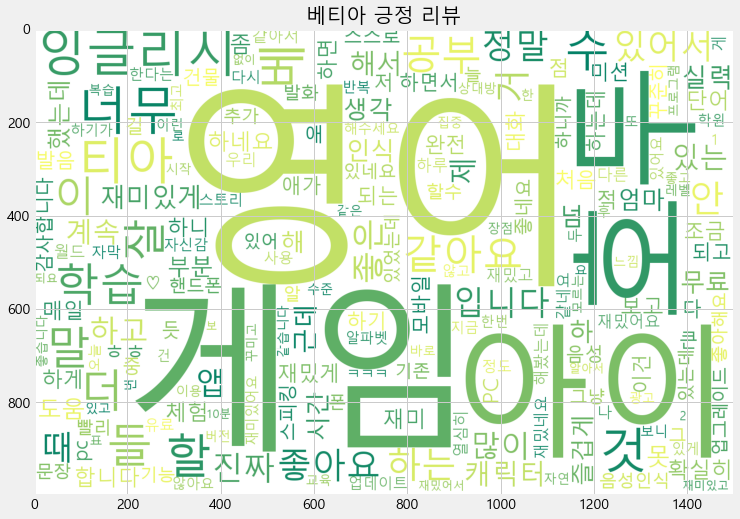

In [60]:
def makeWords(dataframe):
    sentences = []
    words = []
    for cp in tqdm(dataframe['content']):
        sentences.append(okt.pos(cp))
    for sentence in tqdm(sentences):
        for word, tag in sentence:
            if tag not in ['Josa', 'Punctuation']:
                words.append(word)
    return words

# 3점이하 부정적 리뷰
words_bad = makeWords(df[df['rating']<4].dropna())
countword_bad = Counter(words_bad)
makeWordcloud(countword_bad, cmap='winter', title='베티아 부정 리뷰')

# 4점이상 긍정적 리뷰
words_good = makeWords(df[df['rating']>3].dropna())
countword_good = Counter(words_good)
makeWordcloud(countword_good, cmap='summer', title='베티아 긍정 리뷰')

### 긍정, 부정 리뷰 비율

In [77]:
# 별점에 따른 평가 컬럼 추가
df['eval']=np.nan
for row in df.index:
    if df.loc[row, 'rating']>3:
        df.loc[row, 'eval'] = 'positive'
    else:
        df.loc[row, 'eval'] = 'negative'

print('완료')

완료


In [78]:
df

,id,date,rating,userName,content,eval
0,1,2022-02-10,4,반혜영,업데이트 하라고 해서 했는데 자꾸 업데이트 하라고 나오고 앱스토어에는 이미 되어있다...,positive
1,2,2022-01-25,5,Jessica Cha,영어공부에 대한 진입장벽이 거의 없고 게임인듯 게임아닌 영어공부를 할 수 있어서 좋...,positive
2,3,2021-12-23,5,Hil Sa,할 게임 없나 찾아보다 발견해서 20분 정도 해본 거 같아요. 게임은 요즘 게임들처...,positive
3,4,2021-12-31,5,나영,영어게임 중 가장 좋은 거 같아요! 근데 그 스토리 빼고 다 유료인가요..? 한 번...,positive
4,5,2021-12-17,5,박범진,그냥 게임인줄 알고 베티아 잉글리시를 해보니 1. 아이들 뿐 아니라 남녀노소 영어 ...,positive
...,...,...,...,...,...,...
287,288,2021-12-11,5,이현주,굿,positive
288,289,2021-12-08,5,JOY HONG,영어재밌당,positive
289,290,2021-12-20,1,신용준,이거애들이 영어못하는데왜 다른부모님이이거만들앤들이다영어못해그만그만들어엥,negative
290,291,2021-12-24,3,마니,I think this is for preschool. It might be bet...,negative


In [79]:
df_eval = df.groupby('eval').count()
df_eval

,id,date,rating,userName,content
eval,,,,,
negative,51,51,51,51,51
positive,241,241,241,241,241


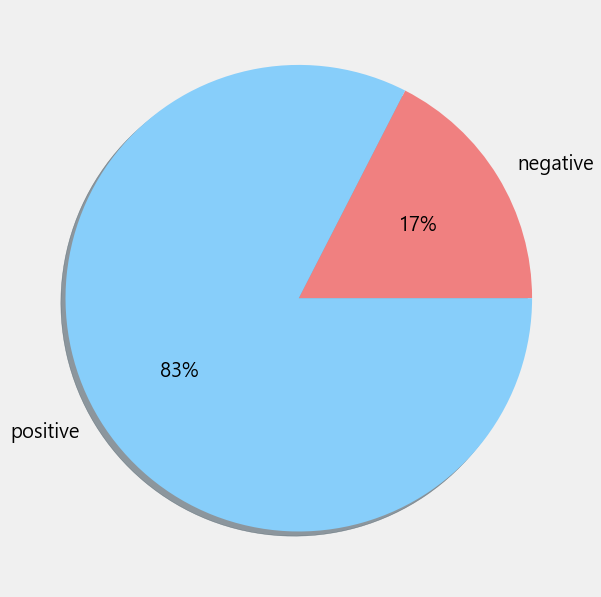

In [80]:
plt.figure(figsize=(10, 10))
plt.pie(df_eval['id'],
        labels=df_eval.index,
        colors=['lightcoral', 'lightskyblue'],
        autopct='%1.0f%%',
        shadow=True,
        textprops={'fontsize':20})
plt.show()

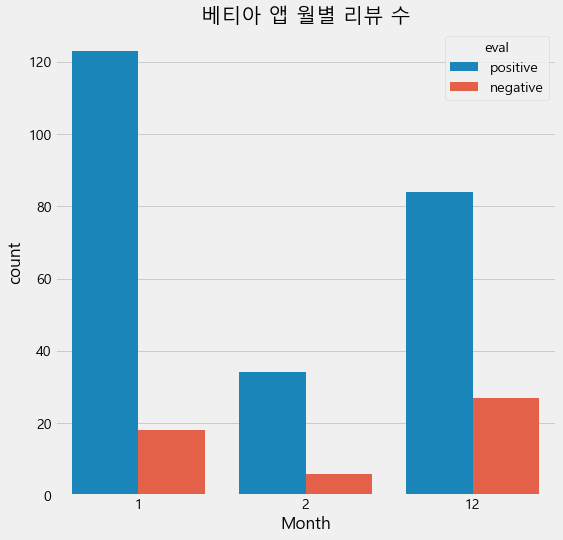

In [81]:
# 월별 평가수 살펴보기
plt.figure(figsize=(8, 8))
# df.groupby([df.date.dt.year, df.date.dt.month]).count()['date'].plot(kind='bar')
sns.countplot(x=df.date.dt.month, hue="eval", data=df)
plt.xlabel('Month')
plt.title('베티아 앱 월별 리뷰 수')
plt.show()

In [105]:
df.groupby([df.date.dt.year, df.date.dt.month])['eval'].count()

date  date
2021  12      111
2022  1       141
      2        40
Name: eval, dtype: int64

In [107]:
df.head()

,id,date,rating,userName,content,eval,date1
0,1,2022-02-10,4,반혜영,업데이트 하라고 해서 했는데 자꾸 업데이트 하라고 나오고 앱스토어에는 이미 되어있다...,positive,2022-02-01
1,2,2022-01-25,5,Jessica Cha,영어공부에 대한 진입장벽이 거의 없고 게임인듯 게임아닌 영어공부를 할 수 있어서 좋...,positive,2022-01-01
2,3,2021-12-23,5,Hil Sa,할 게임 없나 찾아보다 발견해서 20분 정도 해본 거 같아요. 게임은 요즘 게임들처...,positive,2021-12-01
3,4,2021-12-31,5,나영,영어게임 중 가장 좋은 거 같아요! 근데 그 스토리 빼고 다 유료인가요..? 한 번...,positive,2021-12-01
4,5,2021-12-17,5,박범진,그냥 게임인줄 알고 베티아 잉글리시를 해보니 1. 아이들 뿐 아니라 남녀노소 영어 ...,positive,2021-12-01


In [126]:
# df_by_group_label = df_by_group_label.reset_index()
# df_pivot = df_by_group_label.pivot(index='group',columns='label',values='xval')
# df_pivot

df1 = df.groupby(['date1', 'eval'])['id'].count().reset_index()
df1

,date1,eval,id
0,2021-12-01,negative,27
1,2021-12-01,positive,84
2,2022-01-01,negative,18
3,2022-01-01,positive,123
4,2022-02-01,negative,6
5,2022-02-01,positive,34


<AxesSubplot:xlabel='date1'>

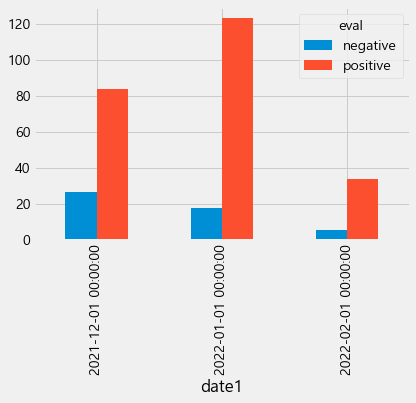

In [ ]:
student_card = pd.DataFrame({'ID':[20190103, 20190222, 20190531],
                             'name':['Kim', 'Lee', 'Jeong'],
                             'class':['H', 'W', 'S']}, index = ['a', 'b', 'c'])   #index 지정

pd.DataFrame({'ID':[20190103, 20190222, 20190531],
                             'name':['Kim', 'Lee', 'Jeong'],
                             'class':['H', 'W', 'S']}, index = ['a', 'b', 'c'])   #index 지정


## 데이터 저장

### 부정적 리뷰 저장

In [95]:
df_neg = df[df['rating']<4]
df_neg.to_csv('./dataset/review_negative.csv', index=False)